In [100]:
import gtsam
import numpy as np
import matplotlib.pyplot as plt
import os
from data_loader import DataLoader
from gtsam.symbol_shorthand import B, V, X
from gtsam import NavState, Pose3, Rot3, Point3
from gtsam.utils.plot import plot_pose3, set_axes_equal
from mpl_toolkits.mplot3d import Axes3D
from typing import Optional, List
from functools import partial
# %matplotlib qt

Set the dataset path

In [101]:
DATA_DIR = "./full_dataset"
DataLoader.get_dir(DATA_DIR)

Data directory set to: ./full_dataset


In [102]:
# read sensor data
imu_file =  "imu_adis_ros.csv"
dvl_file =  "dvl_linkquest.csv"
depth_file =  "depth_sensor.csv"
odom_file = "odometry.csv"

imu = DataLoader.read_imu(imu_file)
dvl = DataLoader.read_dvl(dvl_file)
depth = DataLoader.read_depth(depth_file)
odom = DataLoader.read_odom(odom_file)

# print(imu)

Time synchronization -> choose imu time to be the baseline

In [103]:
# time synchronization
start_time = imu['time'][0]

# print(f"Start time: {start_time}")
# offeset all timestamps to start from zero
imu['time'] -= start_time
dvl['time'] -= start_time
depth['time'] -= start_time
odom['time'] -= start_time

# show new time
print(f"New start time: {imu['time'][0]}")
print(f"New end time: {imu['time'][-1]}")

# convert nanoseconds to seconds
imu['time'] /= 1e9
dvl['time'] /= 1e9
depth['time'] /= 1e9
odom['time'] /= 1e9

# print
print(f"IMU time range: {imu['time'][0]} to {imu['time'][-1]}")

New start time: 0.0
New end time: 1955073564672.0
IMU time range: 0.0 to 1955.073564672


Set initial values (biases and noises) for preintegrated imu

In [104]:
# state initialization
# biases
accBias = np.array([0.067, 0.115, 0.32])
gyroBias = np.array([0.067, 0.115, 0.32])
bias = gtsam.imuBias.ConstantBias(accBias, gyroBias)

# set gravity
pim_params = gtsam.PreintegrationParams.MakeSharedU(9.81)

# Some arbitrary noise sigmas
gyro_sigma = 1e-3
accel_sigma = 1e-3
I_3x3 = np.eye(3)
pim_params.setGyroscopeCovariance(gyro_sigma**2 * I_3x3)
pim_params.setAccelerometerCovariance(accel_sigma**2 * I_3x3)
pim_params.setIntegrationCovariance(1e-7**2 * I_3x3)

# preintegrate imu measurements
pim = gtsam.PreintegratedImuMeasurements(pim_params, bias)

# Noise models for factors
priorNoise = gtsam.noiseModel.Isotropic.Sigma(6, 0.1)
velNoise = gtsam.noiseModel.Isotropic.Sigma(3, 0.1)

Main loop for preintegrating imu

In [105]:
def main_loop(graph, initial):
    # add prior initial node from odometry
    init_pose = Pose3(
        Rot3.Quaternion(
            odom['qw'][0],
            odom['qx'][0],
            odom['qy'][0],
            odom['qz'][0],
        ),
        Point3(
            odom['x'][0],
            odom['y'][0],
            odom['z'][0],
        )
    )

    init_vel = Point3(0.0, 0.0, 0.0)

    init_state = NavState(init_pose, init_vel)

    # add initial graph
    graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
    graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

    # add initial values
    initial.insert(X(0), init_state.pose())
    initial.insert(V(0), init_state.velocity())
    initial.insert(B(0), bias)
    # enumerate imu data
    # set last time
    last_time = imu['time'][0]
    # set initial state
    # prev_state = initial
    prev_state = init_state

    key_index = 0

    # for i in range(1, len(imu['time'])):
    for i in range(1, 100):
        # get measurement data at index i
        dt = imu['time'][i] - imu['time'][i - 1]
        # print(f"dt: {dt}")
        measured_acc = np.array([
            imu['ax'][i],
            imu['ay'][i],
            imu['az'][i],
        ])
        # print(f"measured_acc: {measured_acc}")
        measured_omg = np.array([
            imu['omega_x'][i],
            imu['omega_y'][i],
            imu['omega_z'][i],
        ])
        # print(f"measured_omg: {measured_omg}")

        # integrate measurement
        pim.integrateMeasurement(measured_acc, measured_omg, dt)

        freq = 3.0 # Hz (DVL freq)
        threshold = 1.0 / freq
        current_time = imu['time'][i]
        if current_time - last_time  >= threshold:
            # Create IMU factor every threshold seconds
            factor = gtsam.ImuFactor(X(key_index), V(key_index), X(key_index + 1), V(key_index + 1), B(0), pim)
            graph.push_back(factor)

            # get nav state
            actual_state = pim.predict(prev_state, bias)

            # insert initial estimate
            initial.insert(X(key_index + 1), actual_state.pose())
            initial.insert(V(key_index + 1), actual_state.velocity())
            key_index += 1
            print(f"Inserted key index: {key_index}")
            
            pim.resetIntegration()
            prev_state = actual_state # for next time

            last_time = current_time # for next time
        
        

Create imu graph and run imu preintegration

In [106]:
graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
main_loop(graph, initial)

Inserted key index: 1
Inserted key index: 2
Inserted key index: 3
Inserted key index: 4
Inserted key index: 5
Inserted key index: 6
Inserted key index: 7
Inserted key index: 8
Inserted key index: 9
Inserted key index: 10
Inserted key index: 11
Inserted key index: 12
Inserted key index: 13
Inserted key index: 14
Inserted key index: 15
Inserted key index: 16
Inserted key index: 17
Inserted key index: 18
Inserted key index: 19
Inserted key index: 20
Inserted key index: 21
Inserted key index: 22
Inserted key index: 23
Inserted key index: 24


Some plottings

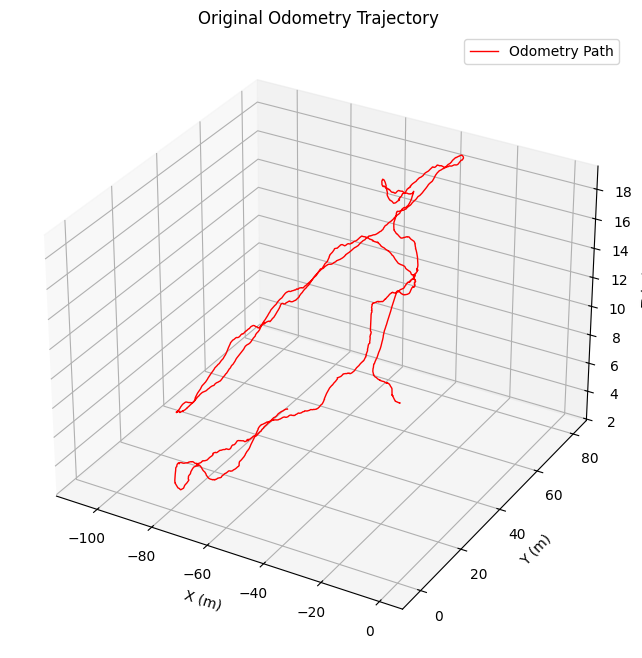

In [107]:
# plot original imu trajectory
def plot_ori_odom():
    xs, ys, zs = [], [], []
    for i in range(len(imu['time'])):
        xs.append(odom['x'][i])
        ys.append(odom['y'][i])
        zs.append(odom['z'][i])
    
    fig = plt.figure(2, figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot(xs, ys, zs, '-r', linewidth=1, label="Odometry Path")
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title("Original Odometry Trajectory")
    ax.legend()
    plt.show()

plot_ori_odom()

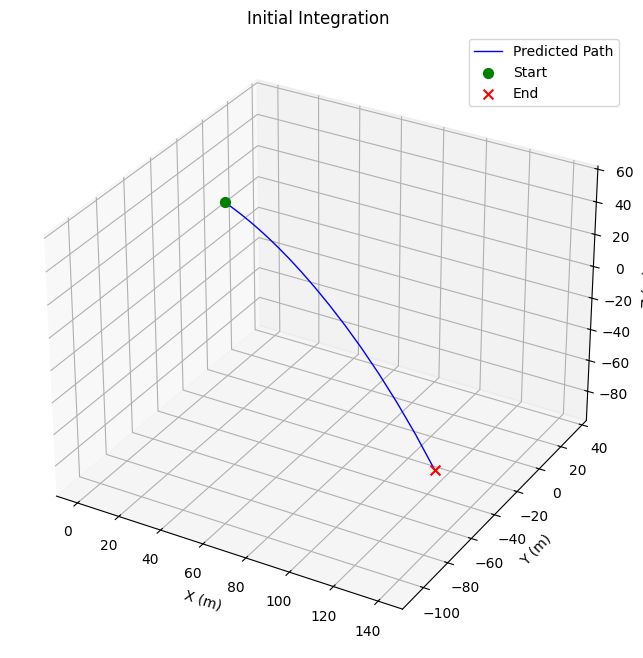

In [108]:
def plot_trajectory_fast(values: gtsam.Values, 
                         title: str = "Trajectory", 
                         fignum: int = 1, 
                         show: bool = True):
    # 1. Create/Get the figure
    fig = plt.figure(fignum, figsize=(10, 8))
    
    # 2. CLEAR the figure to remove any existing 2D axes
    fig.clf() 
    
    # 3. Explicitly add a 3D subplot
    ax = fig.add_subplot(111, projection='3d')
    
    xs, ys, zs = [], [], []
    i = 0
    
    # Extract data
    while values.exists(X(i)):
        pose = values.atPose3(X(i))
        p = pose.translation()
        
        xs.append(p[0])
        ys.append(p[1])
        zs.append(p[2])
        i += 1
    
    if len(xs) == 0:
        print("No poses found!")
        return

    # Plot the path line
    ax.plot(xs, ys, zs, '-b', linewidth=1, label="Predicted Path")
    
    # Mark Start (Green) and End (Red)
    # Note: On a 3D axis, scatter accepts (x, y, z)
    ax.scatter(xs[0], ys[0], zs[0], c='g', marker='o', s=50, label="Start")
    ax.scatter(xs[-1], ys[-1], zs[-1], c='r', marker='x', s=50, label="End")

    # Labels and Title
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m)')
    ax.set_title(title)
    ax.legend()
    
    # Equal Aspect Ratio (Try/Except in case utils are missing)
    try:
        gtsam.utils.plot.set_axes_equal(fignum)
    except:
        pass
        
    if show:
        plt.show()

# Run it
plot_trajectory_fast(initial, title="Initial Integration", fignum=1)

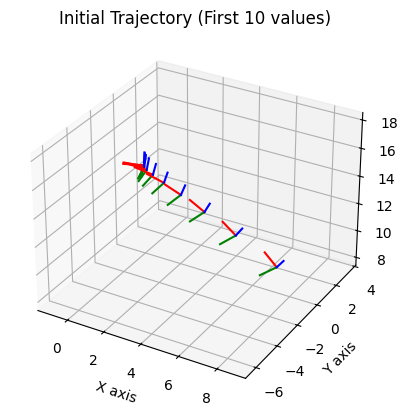

In [109]:
def plot_trajectory(values: gtsam.Values,
                    title: str = "Estimated Trajectory",
                    fignum: int = 1,
                    limit: int = 100, # <--- Limit parameter
                    show: bool = False):
    i = 0
    # Run while key exists AND i is less than limit
    while values.exists(X(i)) and i < limit:
        pose_i = values.atPose3(X(i))
        plot_pose3(fignum, pose_i, 1)
        i += 1
        
    plt.title(f"{title} (First {i} values)")

    gtsam.utils.plot.set_axes_equal(fignum)

    plt.ioff()

    if show:
        plt.show()

# Usage: Plot only the first 100 values
plot_trajectory(initial, title="Initial Trajectory", fignum=7, limit=10, show=True)


In [110]:
# optimize the graph    
lm_params = gtsam.LevenbergMarquardtParams()
lm_params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, lm_params)
result = optimizer.optimize()

Initial error: 1.2e-26, values: 51
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20      1e-05      1          0
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20     0.0001      1          0
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20      0.001      1          0
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20       0.01      1          0
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20        0.1      1          0
iter      cost      cost_change    lambda  success iter_time
   0      2.3e-20     -2.3e-20          1      1          0
iter      cost      cost_change    lambda  success iter_time
   0      1.7e-20     -1.7e-20         10      1          0
iter      cost      cost_change    lambda  success iter_time
   0      1.7e-20     -1.7e-20      1e+02      1         

As you can see, the error grows very fast. So, the position should be corrected by adding the velocity.

Add noise model for DVL and depth sensor

In [111]:
# arbitary noise models for depth and dvl
depth_noise_model = gtsam.noiseModel.Isotropic.Sigma(1, 0.001) # 0.1 cm stddev
dvl_noise_model = gtsam.noiseModel.Isotropic.Sigma(3, 0.01) # 1 cm/s stddev

# create error definition for depth and velocity
def depth_error(
        measurement: np.ndarray,
        this: gtsam.CustomFactor,
        values: gtsam.Values,
        jacobians: Optional[List[np.ndarray]],
    ) -> float:
        """
        Calculate the error betwen the depth sensor and the depth prediction
        """
        # Measurement is >0, meaning that it should be inverted
        assert measurement <= 0, "Measurement should be negative"
        key = this.keys()[0]
        estimate = values.atPose3(key)
        depth = estimate.z()
        error = measurement - depth
        if jacobians is not None:
            val = np.zeros((1, 6))
            val[0, 2] = 1
            jacobians[0] = val
        return error

def velocity_error(
        measurement: np.ndarray,
        this: gtsam.CustomFactor,
        values: gtsam.Values,
        jacobians: Optional[List[np.ndarray]],
    ) -> float:
        """
        Calculate the error betwen the velocity prediction and the velocity measurement
        """
        key = this.keys()[0]
        vel_estimate = values.atPoint3(V(key))
        pose_estimate = values.atPose3(X(key))

        rot_mat = pose_estimate.rotation().matrix()
        vx = vel_estimate[0]
        vy = vel_estimate[1]
        vz = vel_estimate[2]
        v = np.array([vx, vy, vz]).reshape((3, 1))

        meas_t = measurement.T
        meas_world = rot_mat @ meas_t

        error = np.array(
            [
                meas_world[0, 0] - v[0, 0],
                meas_world[1, 0] - v[1, 0],
                meas_world[2, 0] - v[2, 0],
            ]
        )
        if jacobians is not None:
            jacobians[0] = rot_mat
        return error

In [112]:
# modify main loop to add depth and dvl factors

def new_main_loop(graph, initial):
    # add prior initial node from odometry
    init_pose = Pose3(
        Rot3.Quaternion(
            odom['qw'][0],
            odom['qx'][0],
            odom['qy'][0],
            odom['qz'][0],
        ),
        Point3(
            odom['x'][0],
            odom['y'][0],
            odom['z'][0],
        )
    )

    init_vel = Point3(0.0, 0.0, 0.0)

    init_state = NavState(init_pose, init_vel)

    # add initial graph
    graph.push_back(gtsam.PriorFactorPose3(X(0), init_state.pose(), priorNoise)) # position
    graph.push_back(gtsam.PriorFactorVector(V(0), init_state.velocity(), velNoise)) # velocity

    # add initial values
    initial.insert(X(0), init_state.pose())
    initial.insert(V(0), init_state.velocity())
    initial.insert(B(0), bias)
    # enumerate imu data
    # set last time
    last_time = imu['time'][0]
    # set initial state
    # prev_state = initial
    prev_state = init_state

    key_index = 0

    for i in range(1, len(imu['time'])):
    # for i in range(1, 100):
        # get measurement data at index i
        dt = imu['time'][i] - imu['time'][i - 1]
        # print(f"dt: {dt}")
        measured_acc = np.array([
            imu['ax'][i],
            imu['ay'][i],
            imu['az'][i],
        ])
        # print(f"measured_acc: {measured_acc}")
        measured_omg = np.array([
            imu['omega_x'][i],
            imu['omega_y'][i],
            imu['omega_z'][i],
        ])
        # print(f"measured_omg: {measured_omg}")

        # integrate measurement
        pim.integrateMeasurement(measured_acc, measured_omg, dt)

        freq = 3.0 # Hz (DVL freq)
        threshold = 1.0 / freq
        current_time = imu['time'][i]

        # time thrshold for dvl and depth
        time_threshold = 1e-4
        
        if current_time - last_time  >= threshold:

            ####### Add imu factor #######

            # Create IMU factor every threshold seconds
            factor = gtsam.ImuFactor(X(key_index), V(key_index), X(key_index + 1), V(key_index + 1), B(0), pim)
            graph.push_back(factor)

            # get nav state
            actual_state = pim.predict(prev_state, bias)

            ####### Add depth factor #######
            
            # find closet time
            depth_idx = (np.abs(depth['time'] - current_time)).argmin()
            depth_value = -1.0 * depth['depth'][depth_idx]
            depth_time = depth['time'][depth_idx]
            
            if abs(depth_time - current_time) < time_threshold:
                # print(f"Adding depth factor at key index {key_index + 1} with depth value {depth_value} at time {depth_time}")
                depth_factor = gtsam.CustomFactor(
                        depth_noise_model,
                        [X(key_index + 1)],
                        partial(depth_error, np.array([depth_value])),
                    )
                
                graph.push_back(depth_factor) 
            
            ####### Add DVL factor #######
            
            
            ####### add initial values #######
            # insert initial estimate
            initial.insert(X(key_index + 1), actual_state.pose())
            initial.insert(V(key_index + 1), actual_state.velocity())
            key_index += 1
            # print(f"Inserted key index: {key_index}")
            
            pim.resetIntegration()
            prev_state = actual_state # for next time

            last_time = current_time # for next time



        
        

In [113]:
# current_time = imu['time'][0]
# depth_idx = (np.abs(depth['time'] - current_time)).argmin()

# print(f"Closest depth index: {depth_idx}, time: {depth['time'][depth_idx]}, depth: {depth['depth'][depth_idx]}")

In [114]:
new_graph = gtsam.NonlinearFactorGraph()
new_initial = gtsam.Values()
new_main_loop(new_graph, new_initial)

# optimize the new graph
lm_params = gtsam.LevenbergMarquardtParams()
lm_params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(new_graph, new_initial, lm_params)
new_result = optimizer.optimize()

Initial error: 5.9e+21, values: 9985
iter      cost      cost_change    lambda  success iter_time
   0      9.6e+26     -9.6e+26      1e-05      1       0.98
iter      cost      cost_change    lambda  success iter_time
   0      3.6e+26     -3.6e+26     0.0001      1       0.92
iter      cost      cost_change    lambda  success iter_time
   0      1.5e+26     -1.5e+26      0.001      1       0.85
iter      cost      cost_change    lambda  success iter_time
   0      9.8e+25     -9.8e+25       0.01      1       0.86
iter      cost      cost_change    lambda  success iter_time
   0      8.2e+25     -8.2e+25        0.1      1       0.78
iter      cost      cost_change    lambda  success iter_time
   0      5.1e+25     -5.1e+25          1      1       0.84
iter      cost      cost_change    lambda  success iter_time
   0      7.9e+24     -7.9e+24         10      1       0.82
iter      cost      cost_change    lambda  success iter_time
   0      2.3e+23     -2.2e+23      1e+02      1       